# Shared Cell Subset

In [1]:
import os
import json
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from upsetplot import UpSet, from_contents

In [2]:
INCLUDE_SR_AUG = True  

ALL_CONDITIONS = {
    'SR_Std': {
        'path': "/mnt/md0/jack-gaa/cellranger/SRR21492166/outs/filtered_feature_bc_matrix/",
        'modality': 'SR', 'reference': 'Standard',
    },
    'SR_Aug': {
        'path': "/mnt/md0/jack-gaa/cellranger/SRR21492166-gaa-augmented/outs/filtered_feature_bc_matrix/",
        'modality': 'SR', 'reference': 'Augmented',
    },
    'SR_Dis': {
        'path': "/mnt/md0/jack-gaa/cellranger/SRR21492166-gaa-discovery/outs/filtered_feature_bc_matrix/",
        'modality': 'SR', 'reference': 'Discovery',
    },
    'LR_Std': {
        'path': "/mnt/md0/jack-gaa/wf-single-cell/SRR21492157-wf-single-cell-v2/output/SRR21492157-data/SRR21492157-data.gene_processed_feature_bc_matrix/",
        'modality': 'LR', 'reference': 'Standard',
    },
    'LR_Aug': {
        'path': "/mnt/md1/jack-gaa2/wf-single-cell-gaa-augmented-31Jul2026/output/SRR21492157-data/SRR21492157-data.gene_processed_feature_bc_matrix/",
        'modality': 'LR', 'reference': 'Augmented',
    },
    'LR_Dis': {
        'path': "/mnt/md1/jack-gaa2/wf-single-cell-gaa-discovery-30Jul2026/output/SRR21492157-data/SRR21492157-data.gene_processed_feature_bc_matrix/",
        'modality': 'LR', 'reference': 'Discovery',
    },
}

CONDITIONS = {name: cfg for name, cfg in ALL_CONDITIONS.items()
              if INCLUDE_SR_AUG or name != 'SR_Aug'}

missing = [name for name, cfg in CONDITIONS.items() if cfg['path'].startswith('TODO')]
if missing:
    print(f"NOTE: paths still TODO for: {missing} — loading will fail until these are filled in.")

print(f"Running with {len(CONDITIONS)}/6 conditions "
      f"({'SR-Augmented included — final run' if INCLUDE_SR_AUG else 'SR-Augmented EXCLUDED — this is a preview run, not final'})")

Running with 6/6 conditions (SR-Augmented included — final run)


In [3]:
adatas = {}
for name, cfg in CONDITIONS.items():
    print(f"Loading {name} ({cfg['modality']}, {cfg['reference']})...")
    adata = sc.read_10x_mtx(cfg['path'], var_names='gene_symbols', cache=True)
    adata.obs['dataset'] = name
    adata.obs['modality'] = cfg['modality']
    adata.obs['reference'] = cfg['reference']
    adatas[name] = adata

for name, cfg in CONDITIONS.items():
    if cfg['reference'] != 'Standard':
        adatas[name].var_names = adatas[name].var_names.str.replace('.tsv', '', regex=False)

print("\n=== Dataset Dim Auditing ===")
for name, adata in adatas.items():
    print(f"{name:8s} -> Cells: {adata.n_obs:,} | Features: {adata.n_vars:,}")

Loading SR_Std (SR, Standard)...
Loading SR_Aug (SR, Augmented)...
Loading SR_Dis (SR, Discovery)...
Loading LR_Std (LR, Standard)...
Loading LR_Aug (LR, Augmented)...
Loading LR_Dis (LR, Discovery)...

=== Dataset Dim Auditing ===
SR_Std   -> Cells: 3,182 | Features: 38,606
SR_Aug   -> Cells: 3,177 | Features: 121,190
SR_Dis   -> Cells: 2,952 | Features: 117,490
LR_Std   -> Cells: 3,180 | Features: 27,389
LR_Aug   -> Cells: 3,124 | Features: 81,614
LR_Dis   -> Cells: 3,122 | Features: 159,670


## Barcode overlap 

,step,dataset_added,cells_remaining_in_intersection
0,1,SR_Std,3182
1,2,SR_Aug,3156
2,3,SR_Dis,2941
3,4,LR_Std,2905
4,5,LR_Aug,2890
5,6,LR_Dis,2890


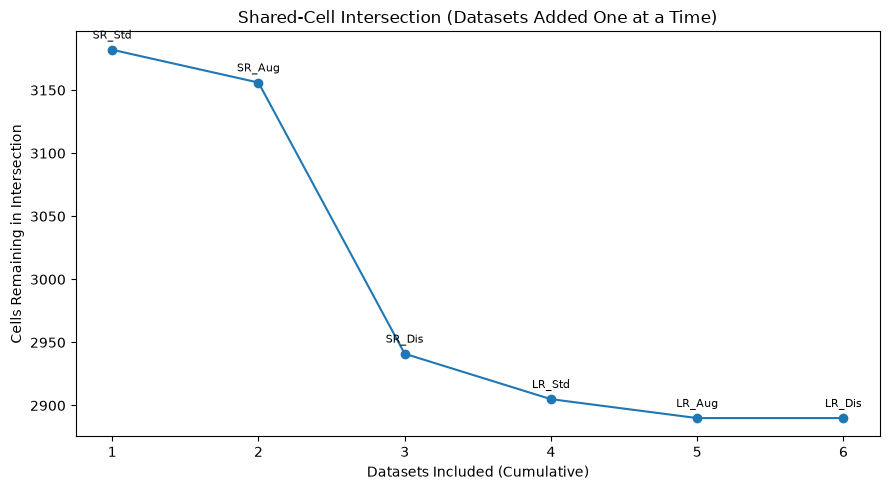


Final 6-way shared barcode count: 2,890


<Figure size 640x480 with 0 Axes>

In [19]:
_MASTER_ORDER = ['SR_Std', 'SR_Aug', 'SR_Dis', 'LR_Std', 'LR_Aug', 'LR_Dis']
ORDER = [name for name in _MASTER_ORDER if name in CONDITIONS]

barcode_sets = {name: set(adatas[name].obs_names) for name in CONDITIONS}

running_set = None
cumulative_rows = []
for name in ORDER:
    s = barcode_sets[name]
    running_set = s if running_set is None else (running_set & s)
    cumulative_rows.append({'step': len(cumulative_rows) + 1,
                             'dataset_added': name,
                             'cells_remaining_in_intersection': len(running_set)})

cum_df = pd.DataFrame(cumulative_rows)
display(cum_df)

plt.figure(figsize=(9, 5))
plt.plot(cum_df['step'], cum_df['cells_remaining_in_intersection'], marker='o')
for _, row in cum_df.iterrows():
    plt.annotate(row['dataset_added'],
                 (row['step'], row['cells_remaining_in_intersection']),
                 textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
plt.xlabel('Datasets Included (Cumulative)')
plt.ylabel('Cells Remaining in Intersection')
plt.title(f"Shared-Cell Intersection (Datasets Added One at a Time)")
plt.xticks(cum_df['step'])
plt.tight_layout()
plt.show()

shared_barcodes = sorted(running_set)
print(f"\nFinal {len(ORDER)}-way shared barcode count: {len(shared_barcodes):,}")


os.makedirs('/mnt/md0/jack-gaa/gaa/analysis/figures/', exist_ok=True)
plt.savefig('/mnt/md0/jack-gaa/gaa/analysis/figures/figure_3_1_shared_cell_intersection.png', dpi=300, bbox_inches='tight')
plt.savefig('/mnt/md0/jack-gaa/gaa/analysis/figures/figure_3_1_shared_cell_intersection.png', dpi=300, bbox_inches='tight')

## Barcode overlap

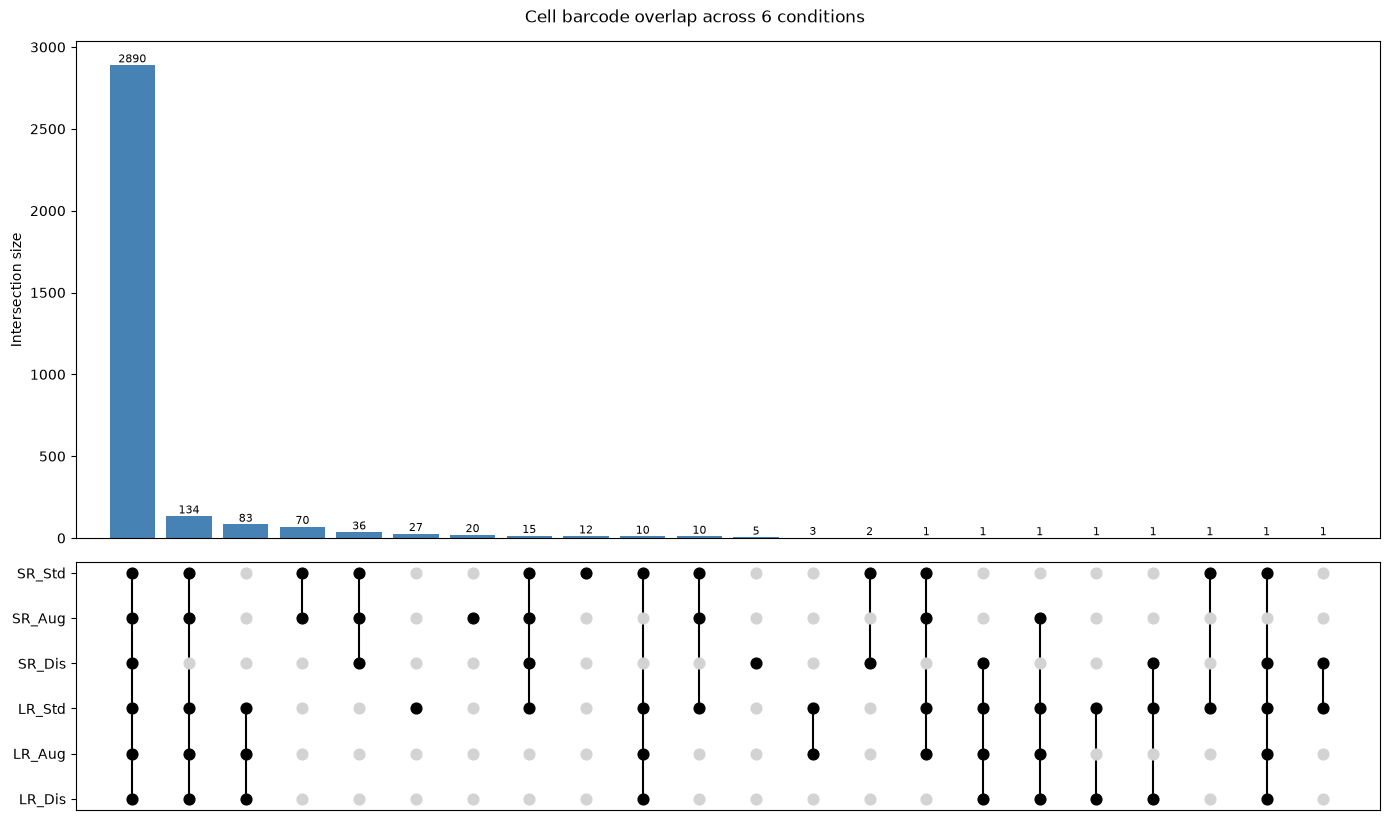

In [5]:
def simple_upset_plot(sets_dict, figsize=(14, 8)):
    """Lightweight UpSet-style plot with no upsetplot dependency."""
    names = list(sets_dict.keys())
    all_elements = set.union(*sets_dict.values())

    membership = {}
    for elem in all_elements:
        combo = tuple(elem in sets_dict[name] for name in names)
        membership[combo] = membership.get(combo, 0) + 1

    combos = sorted(
        [(c, n) for c, n in membership.items() if any(c)],
        key=lambda x: -x[1]
    )

    fig, (ax_bar, ax_dots) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={'height_ratios': [3, 1.5]}
    )

    x = range(len(combos))
    heights = [c[1] for c in combos]
    ax_bar.bar(x, heights, color='steelblue')
    for xi, h in zip(x, heights):
        ax_bar.text(xi, h, str(h), ha='center', va='bottom', fontsize=8)
    ax_bar.set_ylabel('Intersection size')
    ax_bar.set_xticks([])

    for xi, (combo, _) in enumerate(combos):
        active_ys = [yi for yi, in_set in enumerate(combo) if in_set]
        for yi in range(len(names)):
            ax_dots.scatter(xi, yi, color='black' if yi in active_ys else 'lightgray', s=60, zorder=3)
        if len(active_ys) > 1:
            ax_dots.plot([xi, xi], [min(active_ys), max(active_ys)], color='black', zorder=2)

    ax_dots.set_yticks(range(len(names)))
    ax_dots.set_yticklabels(names)
    ax_dots.set_xlim(-1, len(combos))
    ax_dots.invert_yaxis()

    plt.tight_layout()
    return fig

simple_upset_plot(barcode_sets)
plt.suptitle(f"Cell barcode overlap across {len(CONDITIONS)} conditions", y=1.02)
plt.show()

## Pairwise similarity

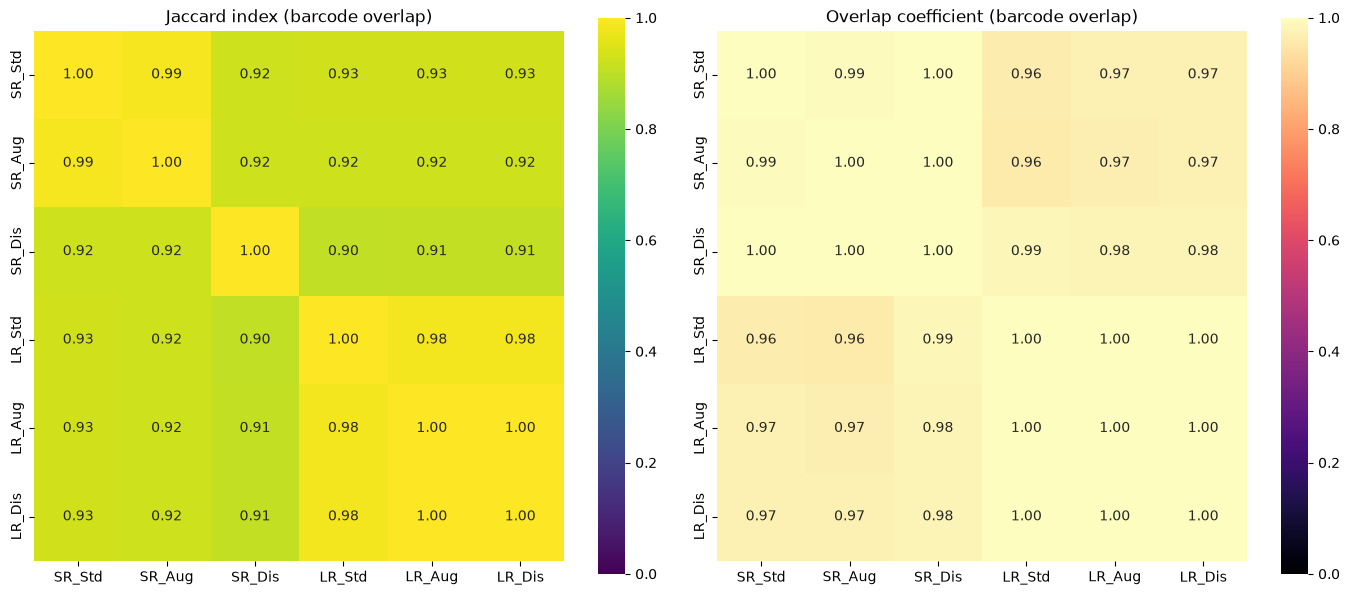

In [6]:
names = list(CONDITIONS.keys())
jaccard = pd.DataFrame(index=names, columns=names, dtype=float)
overlap_coef = pd.DataFrame(index=names, columns=names, dtype=float)

for n1 in names:
    s1 = barcode_sets[n1]
    for n2 in names:
        s2 = barcode_sets[n2]
        inter = len(s1 & s2)
        union = len(s1 | s2)
        jaccard.loc[n1, n2] = inter / union
        overlap_coef.loc[n1, n2] = inter / min(len(s1), len(s2))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(jaccard, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1, square=True, ax=axes[0])
axes[0].set_title('Jaccard index (barcode overlap)')
sns.heatmap(overlap_coef, annot=True, fmt='.2f', cmap='magma', vmin=0, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Overlap coefficient (barcode overlap)')
plt.tight_layout()
plt.show()

## Retention check

In [7]:
condition_sizes = {name: len(s) for name, s in barcode_sets.items()}
smallest_name = min(condition_sizes, key=condition_sizes.get)
smallest_size = condition_sizes[smallest_name]
final_shared = len(shared_barcodes)

pct_retained = 100 * final_shared / smallest_size
print("Per-condition cell counts:")
for name, n in condition_sizes.items():
    print(f"  {name:8s}: {n:,}")

print(f"\nSmallest single condition: {smallest_name} ({smallest_size:,} cells)")
print(f"Final {len(ORDER)}-way shared set: {final_shared:,} cells")
print(f"Retained {pct_retained:.1f}% of the smallest condition's cells "
      f"({100 - pct_retained:.1f}% lost relative to the smallest condition)")

Per-condition cell counts:
  SR_Std  : 3,182
  SR_Aug  : 3,177
  SR_Dis  : 2,952
  LR_Std  : 3,180
  LR_Aug  : 3,124
  LR_Dis  : 3,122

Smallest single condition: SR_Dis (2,952 cells)
Final 6-way shared set: 2,890 cells
Retained 97.9% of the smallest condition's cells (2.1% lost relative to the smallest condition)


## Unified QC 

In [8]:
# --- Subset to the barcode-presence intersection first ---
adatas_shared = {name: adatas[name][shared_barcodes].copy() for name in CONDITIONS}

# --- QC metrics (needed for MAD flagging) ---
for name, adata_obj in adatas_shared.items():
    adata_obj.var['mito'] = adata_obj.var_names.str.startswith('MT-') | adata_obj.var_names.str.startswith('mt-')
    sc.pp.calculate_qc_metrics(adata_obj, qc_vars=['mito'], percent_top=None, log1p=False, inplace=True)


def mad_outlier(adata, metric, n_mads):
    M = adata.obs[metric]
    median = np.median(M)
    mad = np.median(np.abs(M - median))
    if mad == 0:
        return pd.Series(False, index=adata.obs_names)
    return (M < median - n_mads * mad) | (M > median + n_mads * mad)


def flag_qc_outliers(adata):
    a = adata.copy()
    a.obs['log1p_total_counts'] = np.log1p(a.obs['total_counts'])
    a.obs['log1p_n_genes'] = np.log1p(a.obs['n_genes_by_counts'])
    return (
        mad_outlier(a, 'log1p_total_counts', n_mads=5)
        | mad_outlier(a, 'log1p_n_genes', n_mads=5)
        | mad_outlier(a, 'pct_counts_mito', n_mads=3)
    )


outlier_flags = pd.DataFrame(index=shared_barcodes)
for name in CONDITIONS:
    flags = flag_qc_outliers(adatas_shared[name])
    outlier_flags[name] = flags
    print(f"{name}: {flags.sum():,} / {len(flags):,} cells flagged as outliers")

outlier_flags['excluded'] = outlier_flags[list(CONDITIONS.keys())].any(axis=1)
n_excluded = outlier_flags['excluded'].sum()
n_kept = (~outlier_flags['excluded']).sum()
print(f"\nUnified {len(CONDITIONS)}-condition union: {n_excluded:,} excluded, "
      f"{n_kept:,} retained ({100 * n_kept / len(outlier_flags):.1f}% of the "
      f"{len(shared_barcodes):,}-cell shared set)")

qc_pass_barcodes = outlier_flags.index[~outlier_flags['excluded']].tolist()

SR_Std: 480 / 2,890 cells flagged as outliers
SR_Aug: 492 / 2,890 cells flagged as outliers
SR_Dis: 519 / 2,890 cells flagged as outliers
LR_Std: 277 / 2,890 cells flagged as outliers
LR_Aug: 283 / 2,890 cells flagged as outliers
LR_Dis: 330 / 2,890 cells flagged as outliers

Unified 6-condition union: 610 excluded, 2,280 retained (78.9% of the 2,890-cell shared set)


## Subset all active conditions to the final QC-passed barcode set

In [9]:
adatas_sub = {name: adatas_shared[name][qc_pass_barcodes].copy() for name in CONDITIONS}

ref_names = list(adatas_sub.keys())
for name in ref_names[1:]:
    assert all(adatas_sub[ref_names[0]].obs_names == adatas_sub[name].obs_names)
print(f"All {len(CONDITIONS)} conditions aligned on {len(qc_pass_barcodes):,} QC-passed cells")

All 6 conditions aligned on 2,280 QC-passed cells


## QC summary 

In [10]:
qc_rows = []
for name, adata_obj in adatas_sub.items():
    qc_rows.append({
        'condition': name,
        'modality': CONDITIONS[name]['modality'],
        'reference': CONDITIONS[name]['reference'],
        'median_total_counts': adata_obj.obs['total_counts'].median(),
        'median_n_features': adata_obj.obs['n_genes_by_counts'].median(),
        'median_pct_mito': adata_obj.obs['pct_counts_mito'].median(),
    })
qc_summary = pd.DataFrame(qc_rows).set_index('condition')
display(qc_summary)

,modality,reference,median_total_counts,median_n_features,median_pct_mito
condition,,,,,
SR_Std,SR,Standard,4945.500000,2457.0,0.383632
SR_Aug,SR,Augmented,5681.500000,3196.5,0.334805
SR_Dis,SR,Discovery,2451.500000,1986.5,0.586039
LR_Std,LR,Standard,1568.196411,2799.0,0.404116
LR_Aug,LR,Augmented,1845.119995,3704.5,0.339699
LR_Dis,LR,Discovery,2017.191162,4177.5,0.345890


## Cache to disk

In [11]:
OUT_DIR = "/mnt/md0/jack-gaa/gaa/analysis/shared_6way_qc_unified/"
os.makedirs(OUT_DIR, exist_ok=True)

for name, adata_obj in adatas_sub.items():
    adata_obj.write_h5ad(os.path.join(OUT_DIR, f"{name}.h5ad"))

with open(os.path.join(OUT_DIR, "qc_pass_barcodes.json"), "w") as f:
    json.dump(qc_pass_barcodes, f)

print(f"Saved {len(adatas_sub)} QC'd .h5ad files + qc_pass_barcodes list to {OUT_DIR}")

Saved 6 QC'd .h5ad files + qc_pass_barcodes list to /mnt/md0/jack-gaa/gaa/analysis/shared_6way_qc_unified/


In [12]:
n_conditions_flagged = outlier_flags[list(CONDITIONS.keys())].sum(axis=1)
print(n_conditions_flagged[outlier_flags['excluded']].value_counts().sort_index())

1     73
2     39
3    208
4     55
5     24
6    211
Name: count, dtype: int64
